In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [11]:

df_ml = pd.read_csv('ml_ready_stat_data.csv')

In [12]:
# feature x and target y selection
x = df_ml[['time_index' , 'sales_last_month']]
y = df_ml['total_sales']

In [13]:
# train-test split (shuffle=False is mendetory)
x_train, x_test , y_train , y_test  = train_test_split(x, y,test_size=0.2, random_state=42)


In [14]:
# linear regression model training
model = LinearRegression()
model.fit(x_train , y_train)

LinearRegression()

In [15]:
# prediction and evaluation
prediction = model.predict(x_test)
mae = mean_absolute_error(y_test , prediction)
r2 = r2_score(y_test , prediction)

print(f"model succesfully train!!")
print(f"mean absolute error::{mae:.2f}")
print(f"r2 score::{r2:.2f}")

model succesfully train!!
mean absolute error::139053.92
r2 score::0.77


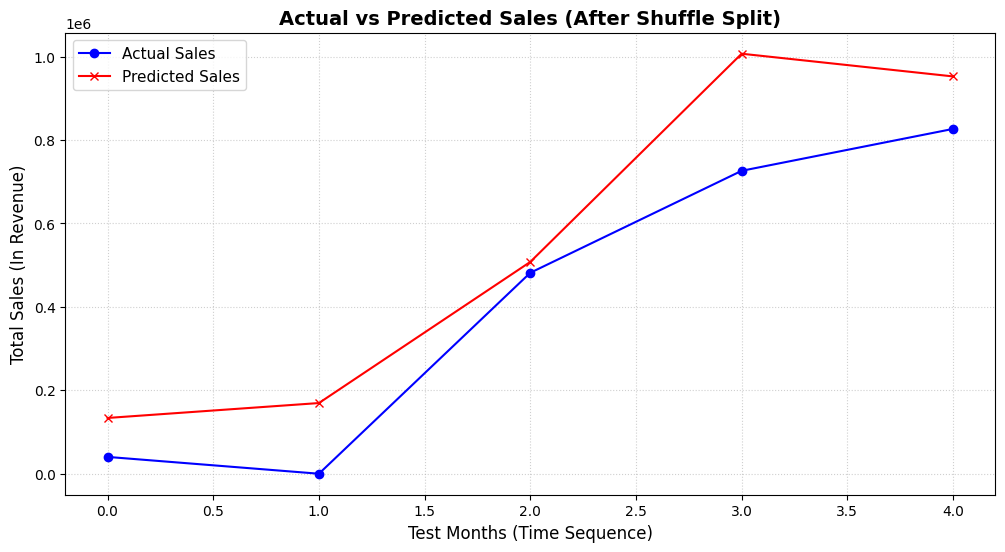

In [18]:
import matplotlib.pyplot as plt

# 1. Actual aur Predicted values ko ek naye DataFrame me daalo
plot_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': prediction
})

# 2. Index ke hisaab se sort karo taaki time ka sequence wapas sahi ho jaye
plot_df = plot_df.sort_index()

# 3. Graph plot karo
plt.figure(figsize=(12, 6))

# Actual Sales ki blue line
plt.plot(plot_df['Actual'].values, label='Actual Sales', marker='o', color='blue')

# Predicted Sales ki red dashed line
plt.plot(plot_df['Predicted'].values, label='Predicted Sales', marker='x', color='red')

# Graph ke labels aur title
plt.title('Actual vs Predicted Sales (After Shuffle Split)', fontsize=14, fontweight='bold')
plt.xlabel('Test Months (Time Sequence)', fontsize=12)
plt.ylabel('Total Sales (In Revenue)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

# Graph show karne ke liye
plt.show()

In [20]:
import pickle

# Model ko ek permanent file me save karne ke liye
with open('linear_regression_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model successfully save, file naam: 'linear_regression_model.pkl'")

Model successfully save, file naam: 'linear_regression_model.pkl'
